In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)

In [37]:
df = pd.read_csv('../data/Uber_DS.csv')

print(df.shape)
df.head()


(200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5000,2015-05-07 19:52:06 UTC,-73.9998,40.7384,-73.9995,40.7232,1
1,27835199,04:56.0,7.7000,2009-07-17 20:04:56 UTC,-73.9944,40.7282,-73.9947,40.7503,1
2,44984355,45:00.0,12.9000,2009-08-24 21:45:00 UTC,-74.0050,40.7408,-73.9626,40.7726,1
3,25894730,22:21.0,5.3000,2009-06-26 08:22:21 UTC,-73.9761,40.7908,-73.9653,40.8033,3
4,17610152,47:00.0,16.0000,2014-08-28 17:47:00 UTC,-73.9250,40.7441,-73.9731,40.7612,5


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [39]:
df.describe()


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.0000,200000.0000,200000.0000,200000.0000,199999.0000,199999.0000,200000.0000
mean,27712503.6823,11.3600,-72.5276,39.9359,-72.5253,39.9239,1.6845
std,16013822.2128,9.9018,11.4378,7.7205,13.1174,6.7948,1.3860
min,1.0000,-52.0000,-1340.6484,-74.0155,-3356.6663,-881.9855,0.0000
25%,13825346.2500,6.0000,-73.9921,40.7348,-73.9914,40.7338,1.0000
50%,27745495.0000,8.5000,-73.9818,40.7526,-73.9801,40.7530,1.0000
75%,41555300.7500,12.5000,-73.9672,40.7672,-73.9637,40.7680,2.0000
max,55423567.0000,499.0000,57.4185,1644.4215,1153.5726,872.6976,208.0000


In [40]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [41]:
print("Corridas acima de $100:", (df['fare_amount'] > 100).sum())
print("Corridas acima de $200:", (df['fare_amount'] > 200).sum())
print("Corridas negativas ou zero:", (df['fare_amount'] <= 0).sum())
print("Total de linhas:", len(df))

Corridas acima de $100: 84
Corridas acima de $200: 7
Corridas negativas ou zero: 22
Total de linhas: 200000


In [42]:
print(df['passenger_count'].value_counts().sort_index())

passenger_count
0         709
1      138425
2       29428
3        8881
4        4276
5       14009
6        4271
208         1
Name: count, dtype: int64


In [43]:
print("Longitude zero (pickup):", (df['pickup_longitude'] == 0).sum())
print("Latitude zero (pickup):", (df['pickup_latitude'] == 0).sum())
print("Fora da faixa de longitude valida:", ((df['pickup_longitude'] < -180) | (df['pickup_longitude'] > 180)).sum())
print("Fora da faixa de latitude valida:", ((df['pickup_latitude'] < -90) | (df['pickup_latitude'] > 90)).sum())

Longitude zero (pickup): 3786
Latitude zero (pickup): 3782
Fora da faixa de longitude valida: 7
Fora da faixa de latitude valida: 4


In [44]:
fora_ny = (
    (df['pickup_longitude'] < -74.3) | (df['pickup_longitude'] > -73.7) |
    (df['pickup_latitude'] < 40.5) | (df['pickup_latitude'] > 41.0) |
    (df['dropoff_longitude'] < -74.3) | (df['dropoff_longitude'] > -73.7) |
    (df['dropoff_latitude'] < 40.5) | (df['dropoff_latitude'] > 41.0)
)

print("Registros fora da regiao de NY:", fora_ny.sum())
print("Percentual:", round(fora_ny.sum() / len(df) * 100, 2), "%")

Registros fora da regiao de NY: 4419
Percentual: 2.21 %


In [45]:
df_limpo = df.dropna()

df_limpo = df_limpo[
    (df_limpo['fare_amount'] > 0) &
    (df_limpo['fare_amount'] <= 100) &
    (df_limpo['passenger_count'] >= 1) &
    (df_limpo['passenger_count'] <= 6) &
    (df_limpo['pickup_longitude'].between(-74.3, -73.7)) &
    (df_limpo['pickup_latitude'].between(40.5, 41.0)) &
    (df_limpo['dropoff_longitude'].between(-74.3, -73.7)) &
    (df_limpo['dropoff_latitude'].between(40.5, 41.0))
].copy()

print("Antes:", len(df))
print("Depois:", len(df_limpo))
print("Removidos:", len(df) - len(df_limpo))
print("Percentual removido:", round((len(df) - len(df_limpo)) / len(df) * 100, 2), "%")

Antes: 200000
Depois: 194831
Removidos: 5169
Percentual removido: 2.58 %


In [46]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371 * c


df_limpo['distancia_km'] = haversine(
    df_limpo['pickup_longitude'],
    df_limpo['pickup_latitude'],
    df_limpo['dropoff_longitude'],
    df_limpo['dropoff_latitude']
)

print(df_limpo['distancia_km'].describe())

count   194831.0000
mean         3.3094
std          3.5607
min          0.0000
25%          1.2568
50%          2.1571
75%          3.9054
max         36.6874
Name: distancia_km, dtype: float64


In [47]:
print("Distancia exatamente zero:", (df_limpo['distancia_km'] == 0).sum())
print("Distancia abaixo de 0.1 km:", (df_limpo['distancia_km'] < 0.1).sum())
print("Percentual abaixo de 0.1 km:", round((df_limpo['distancia_km'] < 0.1).sum() / len(df_limpo) * 100, 2), "%")

Distancia exatamente zero: 1958
Distancia abaixo de 0.1 km: 3096
Percentual abaixo de 0.1 km: 1.59 %


In [48]:
df_limpo = df_limpo[df_limpo['distancia_km'] >= 0.1].copy()

print("Linhas restantes:", len(df_limpo))

Linhas restantes: 191735


In [49]:
df_limpo['pickup_datetime'] = pd.to_datetime(df_limpo['pickup_datetime'])

df_limpo['ano'] = df_limpo['pickup_datetime'].dt.year
df_limpo['mes'] = df_limpo['pickup_datetime'].dt.month
df_limpo['dia_semana'] = df_limpo['pickup_datetime'].dt.dayofweek
df_limpo['hora'] = df_limpo['pickup_datetime'].dt.hour

print(df_limpo[['pickup_datetime', 'ano', 'mes', 'dia_semana', 'hora']].head())

            pickup_datetime   ano  mes  dia_semana  hora
0 2015-05-07 19:52:06+00:00  2015    5           3    19
1 2009-07-17 20:04:56+00:00  2009    7           4    20
2 2009-08-24 21:45:00+00:00  2009    8           0    21
3 2009-06-26 08:22:21+00:00  2009    6           4     8
4 2014-08-28 17:47:00+00:00  2014    8           3    17


In [50]:
aeroportos = {
    'JFK': (-73.7781, 40.6413),
    'LGA': (-73.8740, 40.7769),
    'EWR': (-74.1745, 40.6895)
}

df_limpo['eh_aeroporto'] = 0

for nome, (lon, lat) in aeroportos.items():
    dist_pickup = haversine(df_limpo['pickup_longitude'], df_limpo['pickup_latitude'], lon, lat)
    dist_dropoff = haversine(df_limpo['dropoff_longitude'], df_limpo['dropoff_latitude'], lon, lat)
    
    perto = (dist_pickup < 2) | (dist_dropoff < 2)
    df_limpo.loc[perto, 'eh_aeroporto'] = 1

print(df_limpo['eh_aeroporto'].value_counts())
print("Percentual de corridas de aeroporto:", round(df_limpo['eh_aeroporto'].mean() * 100, 2), "%")

eh_aeroporto
0    181188
1     10547
Name: count, dtype: int64
Percentual de corridas de aeroporto: 5.5 %


In [51]:
print(df_limpo.groupby('eh_aeroporto')['fare_amount'].mean())
print(df_limpo.groupby('eh_aeroporto')['distancia_km'].mean())

eh_aeroporto
0    9.7525
1   37.5289
Name: fare_amount, dtype: float64
eh_aeroporto
0    2.7940
1   13.1316
Name: distancia_km, dtype: float64


In [52]:
df_final = df_limpo.drop(columns=['Unnamed: 0', 'key', 'pickup_datetime']).copy()

print(df_final.columns.tolist())
print(df_final.shape)

['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'distancia_km', 'ano', 'mes', 'dia_semana', 'hora', 'eh_aeroporto']
(191735, 12)


In [53]:
df_final.to_csv('../data/uber_tratado.csv', index=False)
print("Arquivo salvo")

Arquivo salvo


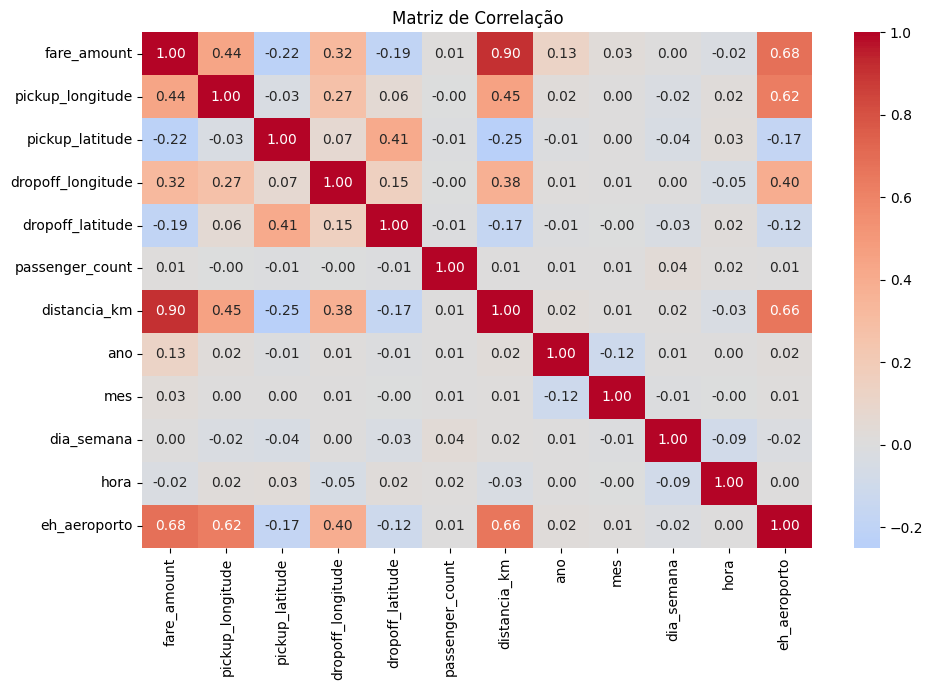

In [54]:
plt.figure(figsize=(10, 7))

matriz_corr = df_final.corr()

sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

In [55]:
from sklearn.linear_model import LinearRegression

features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
            'passenger_count', 'distancia_km', 'ano', 'mes', 'dia_semana', 'hora', 'eh_aeroporto']

X = df_final[features]

for col in features:
    outras = [c for c in features if c != col]
    r2 = LinearRegression().fit(X[outras], X[col]).score(X[outras], X[col])
    vif = 1 / (1 - r2)
    print(f"{col:20s} VIF = {vif:.2f}")

pickup_longitude     VIF = 1.71
pickup_latitude      VIF = 1.27
dropoff_longitude    VIF = 1.32
dropoff_latitude     VIF = 1.28
passenger_count      VIF = 1.00
distancia_km         VIF = 1.96
ano                  VIF = 1.01
mes                  VIF = 1.01
dia_semana           VIF = 1.01
hora                 VIF = 1.01
eh_aeroporto         VIF = 2.46


In [56]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['fare_amount'])
y = df_final['fare_amount']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Treino:", X_treino.shape)
print("Teste:", X_teste.shape)

Treino: (153388, 11)
Teste: (38347, 11)


In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_treino_esc = scaler.fit_transform(X_treino)
X_teste_esc = scaler.transform(X_teste)

print("Media do treino escalonado:", X_treino_esc.mean().round(4))
print("Desvio do treino escalonado:", X_treino_esc.std().round(4))

Media do treino escalonado: -0.0
Desvio do treino escalonado: 1.0


In [58]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_treino_esc, y_treino)

pred_treino_lr = lr.predict(X_treino_esc)
pred_teste_lr = lr.predict(X_teste_esc)

print("Modelo treinado")

Modelo treinado


In [59]:
coefs = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': lr.coef_
}).sort_values('coeficiente', key=abs, ascending=False)

print(coefs)
print("\nIntercepto:", round(lr.intercept_, 2))

              feature  coeficiente
5        distancia_km       7.5394
10       eh_aeroporto       1.6679
6                 ano       0.9758
2   dropoff_longitude      -0.4646
3    dropoff_latitude      -0.3046
1     pickup_latitude       0.2862
0    pickup_longitude      -0.2436
7                 mes       0.2261
8          dia_semana      -0.0661
4     passenger_count       0.0512
9                hora       0.0324

Intercepto: 11.28


In [60]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def avaliar(nome, y_real_treino, pred_treino, y_real_teste, pred_teste):
    print(f"=== {nome} ===")
    print(f"R2 treino:  {r2_score(y_real_treino, pred_treino):.4f}")
    print(f"R2 teste:   {r2_score(y_real_teste, pred_teste):.4f}")
    print(f"MAE:        {mean_absolute_error(y_real_teste, pred_teste):.4f}")
    print(f"RMSE:       {np.sqrt(mean_squared_error(y_real_teste, pred_teste)):.4f}")
    print(f"MAPE:       {mean_absolute_percentage_error(y_real_teste, pred_teste)*100:.2f}%")

avaliar("Regressao Linear", y_treino, pred_treino_lr, y_teste, pred_teste_lr)

=== Regressao Linear ===
R2 treino:  0.8428
R2 teste:   0.8451
MAE:        2.0533
RMSE:       3.6198
MAPE:       24.76%


In [61]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_treino_esc, y_treino)

pred_treino_rf = rf.predict(X_treino_esc)
pred_teste_rf = rf.predict(X_teste_esc)

avaliar("Random Forest", y_treino, pred_treino_rf, y_teste, pred_teste_rf)

=== Random Forest ===
R2 treino:  0.9367
R2 teste:   0.8880
MAE:        1.6506
RMSE:       3.0775
MAPE:       20.78%


In [62]:
importancias = pd.DataFrame({
    'feature': X.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias)

              feature  importancia
5        distancia_km       0.8796
2   dropoff_longitude       0.0306
6                 ano       0.0242
10       eh_aeroporto       0.0156
3    dropoff_latitude       0.0144
0    pickup_longitude       0.0096
9                hora       0.0082
1     pickup_latitude       0.0080
7                 mes       0.0052
8          dia_semana       0.0034
4     passenger_count       0.0012


In [ ]:
from sklearn.svm import SVR

amostra = 20000

X_treino_svr = X_treino_esc[:amostra]
y_treino_svr = y_treino[:amostra]

svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr.fit(X_treino_svr, y_treino_svr)

pred_treino_svr = svr.predict(X_treino_svr)
pred_teste_svr = svr.predict(X_teste_esc)

avaliar("SVR", y_treino_svr, pred_treino_svr, y_teste, pred_teste_svr)

In [ ]:
from sklearn.model_selection import cross_val_score

print("Regressao Linear")
cv_lr = cross_val_score(LinearRegression(), X_treino_esc, y_treino, cv=5, scoring='r2')
print(f"  R2 por fold: {cv_lr.round(4)}")
print(f"  Media: {cv_lr.mean():.4f} | Desvio: {cv_lr.std():.4f}\n")

print("Random Forest")
cv_rf = cross_val_score(
    RandomForestRegressor(n_estimators=50, max_depth=20, min_samples_leaf=5, random_state=42, n_jobs=-1),
    X_treino_esc, y_treino, cv=5, scoring='r2'
)
print(f"  R2 por fold: {cv_rf.round(4)}")
print(f"  Media: {cv_rf.mean():.4f} | Desvio: {cv_rf.std():.4f}\n")

print("SVR")
cv_svr = cross_val_score(
    SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1),
    X_treino_esc[:10000], y_treino[:10000], cv=5, scoring='r2'
)
print(f"  R2 por fold: {cv_svr.round(4)}")
print(f"  Media: {cv_svr.mean():.4f} | Desvio: {cv_svr.std():.4f}")

Regressao Linear
  R2 por fold: [0.8451 0.8475 0.8272 0.846  0.8475]
  Media: 0.8426 | Desvio: 0.0078

Random Forest
  R2 por fold: [0.888  0.8951 0.8722 0.8881 0.8946]
  Media: 0.8876 | Desvio: 0.0083

SVR
  R2 por fold: [0.8508 0.7931 0.8732 0.8604 0.8456]
  Media: 0.8446 | Desvio: 0.0274


In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear Múltipla', 'Random Forest Regressor', 'Support Vector Regressor (SVR)'],
    'R2': [
        r2_score(y_teste, pred_teste_lr),
        r2_score(y_teste, pred_teste_rf),
        r2_score(y_teste, pred_teste_svr)
    ],
    'MAE': [
        mean_absolute_error(y_teste, pred_teste_lr),
        mean_absolute_error(y_teste, pred_teste_rf),
        mean_absolute_error(y_teste, pred_teste_svr)
    ],
    'MAPE (%)': [
        mean_absolute_percentage_error(y_teste, pred_teste_lr) * 100,
        mean_absolute_percentage_error(y_teste, pred_teste_rf) * 100,
        mean_absolute_percentage_error(y_teste, pred_teste_svr) * 100
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_teste, pred_teste_lr)),
        np.sqrt(mean_squared_error(y_teste, pred_teste_rf)),
        np.sqrt(mean_squared_error(y_teste, pred_teste_svr))
    ]
})

resultados = resultados.round(4)
resultados.to_csv('../data/tabela_metricas.csv', index=False)
resultados

,Modelo,R2,MAE,MAPE (%),RMSE
0,Regressão Linear Múltipla,0.8451,2.0533,24.7558,3.6198
1,Random Forest Regressor,0.8880,1.6506,20.7766,3.0775
2,Support Vector Regressor (SVR),0.8674,1.7065,19.5835,3.3490


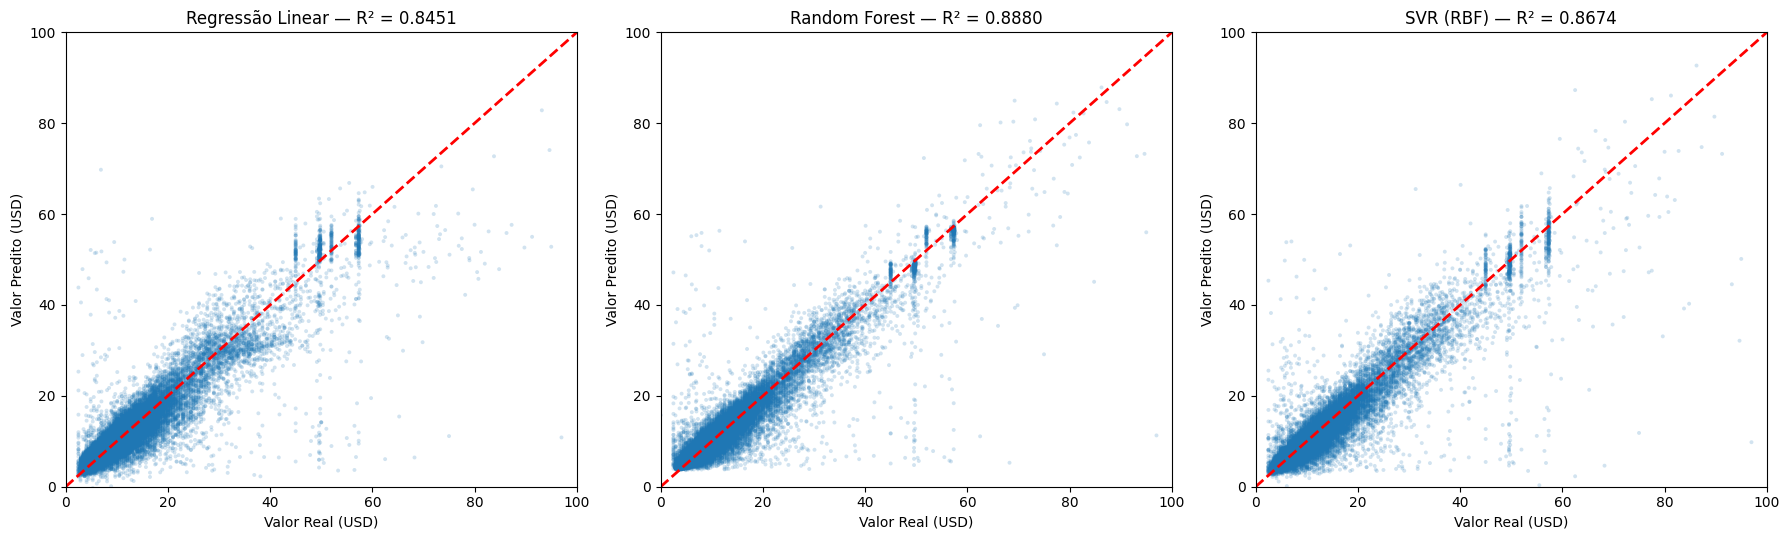

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

modelos = [
    ('Regressão Linear', pred_teste_lr),
    ('Random Forest', pred_teste_rf),
    ('SVR (RBF)', pred_teste_svr)
]

for ax, (nome, pred) in zip(axes, modelos):
    ax.scatter(y_teste, pred, alpha=0.2, s=8, edgecolors='none')
    ax.plot([0, 100], [0, 100], 'r--', linewidth=2)
    ax.set_xlabel('Valor Real (USD)')
    ax.set_ylabel('Valor Predito (USD)')
    ax.set_title(f'{nome} — R² = {r2_score(y_teste, pred):.4f}')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../data/real_vs_predito.png', dpi=150)
plt.show()

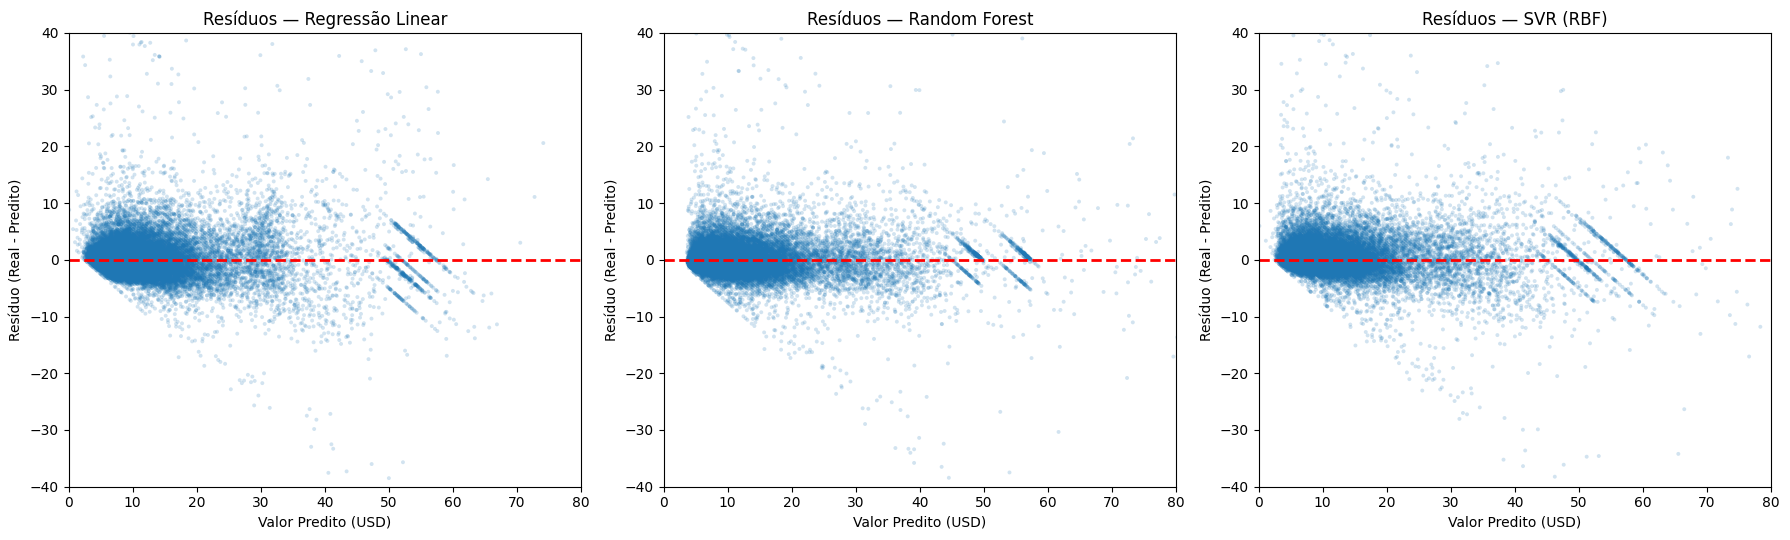

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (nome, pred) in zip(axes, modelos):
    residuos = y_teste - pred
    ax.scatter(pred, residuos, alpha=0.2, s=8, edgecolors='none')
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Valor Predito (USD)')
    ax.set_ylabel('Resíduo (Real - Predito)')
    ax.set_title(f'Resíduos — {nome}')
    ax.set_xlim(0, 80)
    ax.set_ylim(-40, 40)

plt.tight_layout()
plt.savefig('../data/residuos.png', dpi=150)
plt.show()

In [ ]:
import joblib

joblib.dump(rf, '../app/modelo_rf.pkl')
joblib.dump(scaler, '../app/scaler.pkl')
joblib.dump(lr, '../app/modelo_lr.pkl')

print("Artefatos salvos")

Artefatos salvos


In [ ]:
joblib.dump(rf, '../app/modelo_rf.pkl', compress=3)
print("Salvo com compressao")

Salvo com compressao
